
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Faris Sherif/2026 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt

import seaborn as sb

%matplotlib inline

In [3]:
# Load my dataset using pandas Dataframe
df = pd.read_csv("fordgobike-tripdataFor201902.csv")


In [4]:
# here we make overview in high-level for data shape and composition
print(f"the dataset Rows: {df.shape[0]}")
print(f"the dataset Columns: {df.shape[1]}")
df.info()

the dataset Rows: 183416
the dataset Columns: 16
<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year    

In [5]:
## check each var  datatype 
var_datatype = pd.DataFrame({"Data type":df.dtypes})
var_datatype

,Data type
duration_sec,int64
start_time,str
end_time,str
start_station_id,float64
start_station_name,str
start_station_latitude,float64
start_station_longitude,float64
end_station_id,float64
end_station_name,str
end_station_latitude,float64


In [6]:
## I display 15 rows to understand the content values more 
df.head(15)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [7]:
# descriptive statistics for numeric variables
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000




> ### What is the structure of your dataset?





- The structure of the dataset contains 16 columns and 183416 rows.
 
 
- Most variables are numerical in nature , and here are **dtypes summary :**

        - float64(7)
        - int64(2)
        - str(7)
        



> ### What are the main interesting features in the dataset?




 **We got three main feature areas which are :**
 
 
 
 
- User information

- Trip information

- Bike station information





> ### What features in the dataset supported my investigation for these interesting features?



- user_type

- member_gender

- member_birth_year

- duration_sec

- start_station_name and end_station_name



##  More Exploring ideas to begin my investigation

In [8]:
#This code for describing statistical data ideas in a more organized and readable table
desc_stat = pd.DataFrame({
    "Data type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})


In [9]:
# display the information about each column
display(desc_stat)


,Data type,Missing Values,Unique Values
duration_sec,int64,0,4752
start_time,str,0,35783
end_time,str,0,35767
start_station_id,float64,197,329
start_station_name,str,197,329
start_station_latitude,float64,0,334
start_station_longitude,float64,0,335
end_station_id,float64,197,329
end_station_name,str,197,329
end_station_latitude,float64,0,335


## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [10]:
#YOUR CODES
missing_values = df.isnull().sum()
missing_values

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64



> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with Median Value for numeric and Mode Value for categorical

In [11]:
# trying to fill missing values in my datset using for loop 

for col in df.columns:
    if df[col].isnull().sum():
        if df[col].dtype == "str":
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())


In [12]:
#check the Nulls 
missing_values = df.isnull().sum()
missing_values

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

### **And with a proper category for other (member gender)**

In [54]:
##  still got a missing value in the member_gender, so let's explore this column more 

print(df.member_gender.head(15))

0       Male
1       Male
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13      Male
14      Male
Name: member_gender, dtype: str


In [55]:
# fill  dataset with missing values.
df['member_gender'] = df['member_gender'].replace(['', 'nan', 'NaN'], np.nan).fillna('Other')

In [57]:
print(df.member_gender.head(15))

0       Male
1       Male
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13      Male
14      Male
Name: member_gender, dtype: str


In [58]:
## check my result above 
df['member_gender'].isna().sum()


np.int64(0)

> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [69]:
##  check duplicate in dataset
print("The numbers of duplicated columns:", df.duplicated().sum())

The numbers of duplicated columns: 4


In [72]:
df = df.drop_duplicates()
print("The numbers of duplicated columns:", df.duplicated().sum())

The numbers of duplicated columns: 0


> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [76]:
### check the category columns that included object
category_cols = df.select_dtypes(include=['object']).columns.tolist()
category_cols


C:\Users\Fahd\AppData\Local\Temp\ipykernel_16620\443186585.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols = df.select_dtypes(include=['object']).columns.tolist()


['start_time',
 'end_time',
 'start_station_name',
 'end_station_name',
 'user_type',
 'member_gender',
 'bike_share_for_all_trip']

 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [79]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.
df["user_type"] = df.user_type.astype('category')
df.member_gender = df.member_gender.astype('category')


In [97]:
## check your work 
df[['user_type', 'member_gender']].dtypes


user_type        category
member_gender    category
dtype: object

In [90]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them

# create a column for users' age depending on the current year
current_year = pd.Timestamp.now().year
df['users_age'] = current_year - df['member_birth_year']

In [91]:
## check your work 
df['users_age']


0         42.0
1         39.0
2         54.0
3         37.0
4         52.0
          ... 
183407    30.0
183408    42.0
183409    36.0
183410    38.0
183411    37.0
Name: users_age, Length: 183412, dtype: float64

In [95]:
## change the new column age data type from float to int
df['users_age'] = df.users_age.astype('int')
df.users_age.dtype


dtype('int64')

In [101]:
## create a function to know the average users ages
def average_users_ages(df):
    return df['users_age'].mean()

average_users_ages(df)

np.float64(41.09471572198111)

In [105]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable
df['duration_min'] = df.duration_sec/60
df.duration_min = df.duration_min.astype('int')


In [106]:
## I need to change the time from second to Houre  to be more usable
df['duration_hour'] = df.duration_min/60
df.duration_hour = df.duration_hour.astype('int')

In [107]:
## check your work 
pd.DataFrame({
    'Duration in sec': df.duration_sec,
    'Duration in min': df.duration_min,
    'Duration in hour': df.duration_hour,
})

,Duration in sec,Duration in min,Duration in hour
0,52185,869,14
1,42521,708,11
2,61854,1030,17
3,36490,608,10
4,1585,26,0
...,...,...,...
183407,480,8,0
183408,313,5,0
183409,141,2,0
183410,139,2,0



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

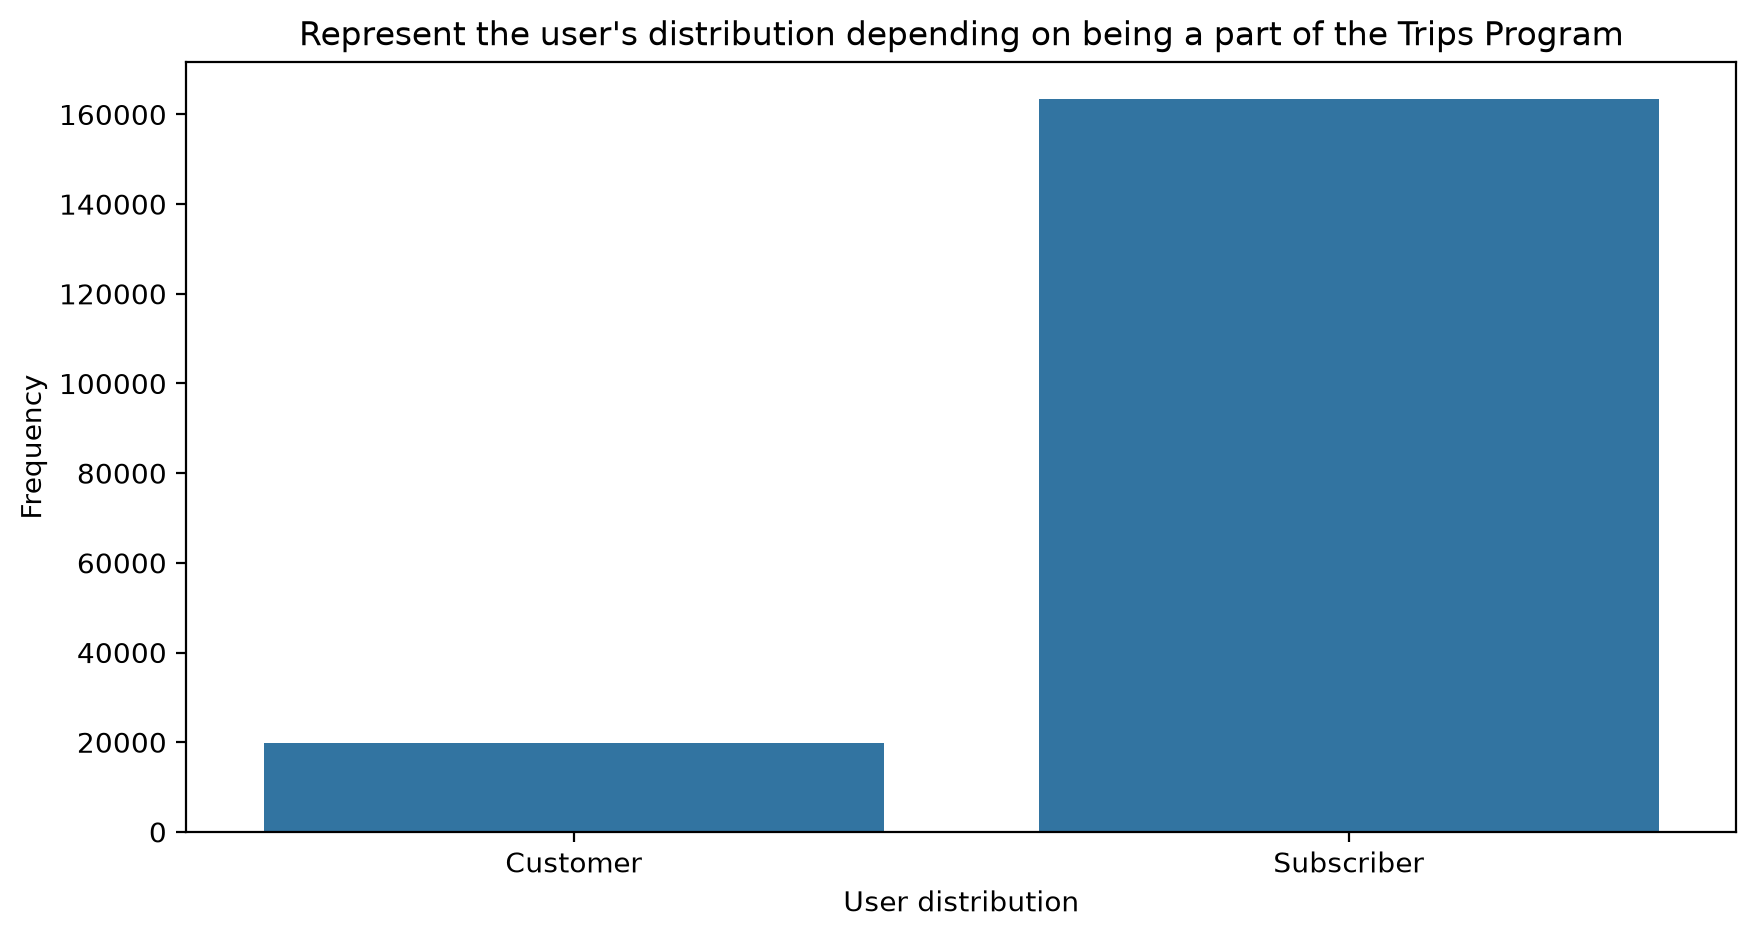

In [114]:
## I will import seaborn library to support me in making visualizations 

import seaborn as sns
plt.figure(figsize = (10,5), dpi = 200)

plot = sns.countplot(data=df, x='user_type')

plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")

plt.show()

> ### Analysis

Subscribers make up the clear majority of users, while Customers represent a much smaller share. This indicates that the service is used mainly by members with a subscription rather than occasional customers.

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

Text(0.5, 1.0, 'Distribution of Bike Share for All Trips')

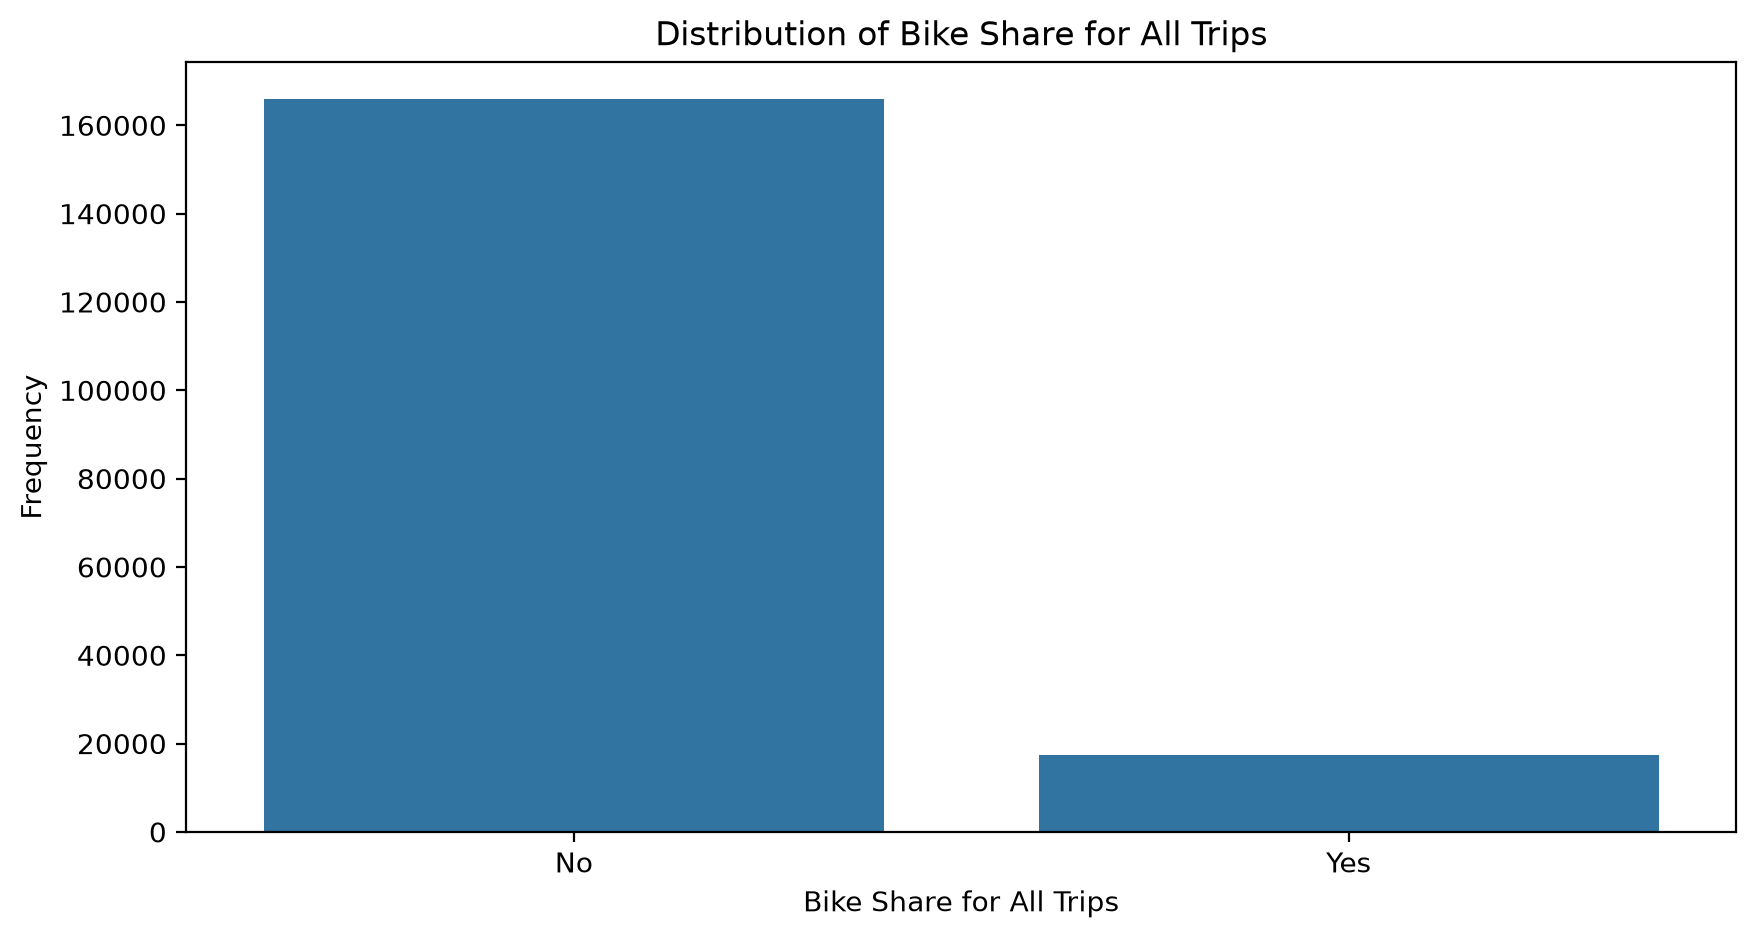

In [115]:
plt.figure(figsize=(10,5), dpi=200)

plot = sns.countplot(data=df, x='bike_share_for_all_trip')

plt.xlabel('Bike Share for All Trips')
plt.ylabel('Frequency')
plt.title("Distribution of Bike Share for All Trips")

> ### Analysis

Most users are not enrolled in the bike-share-for-all program. The `No` category is substantially more common than `Yes`, so the program represents a minority of all trips.

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

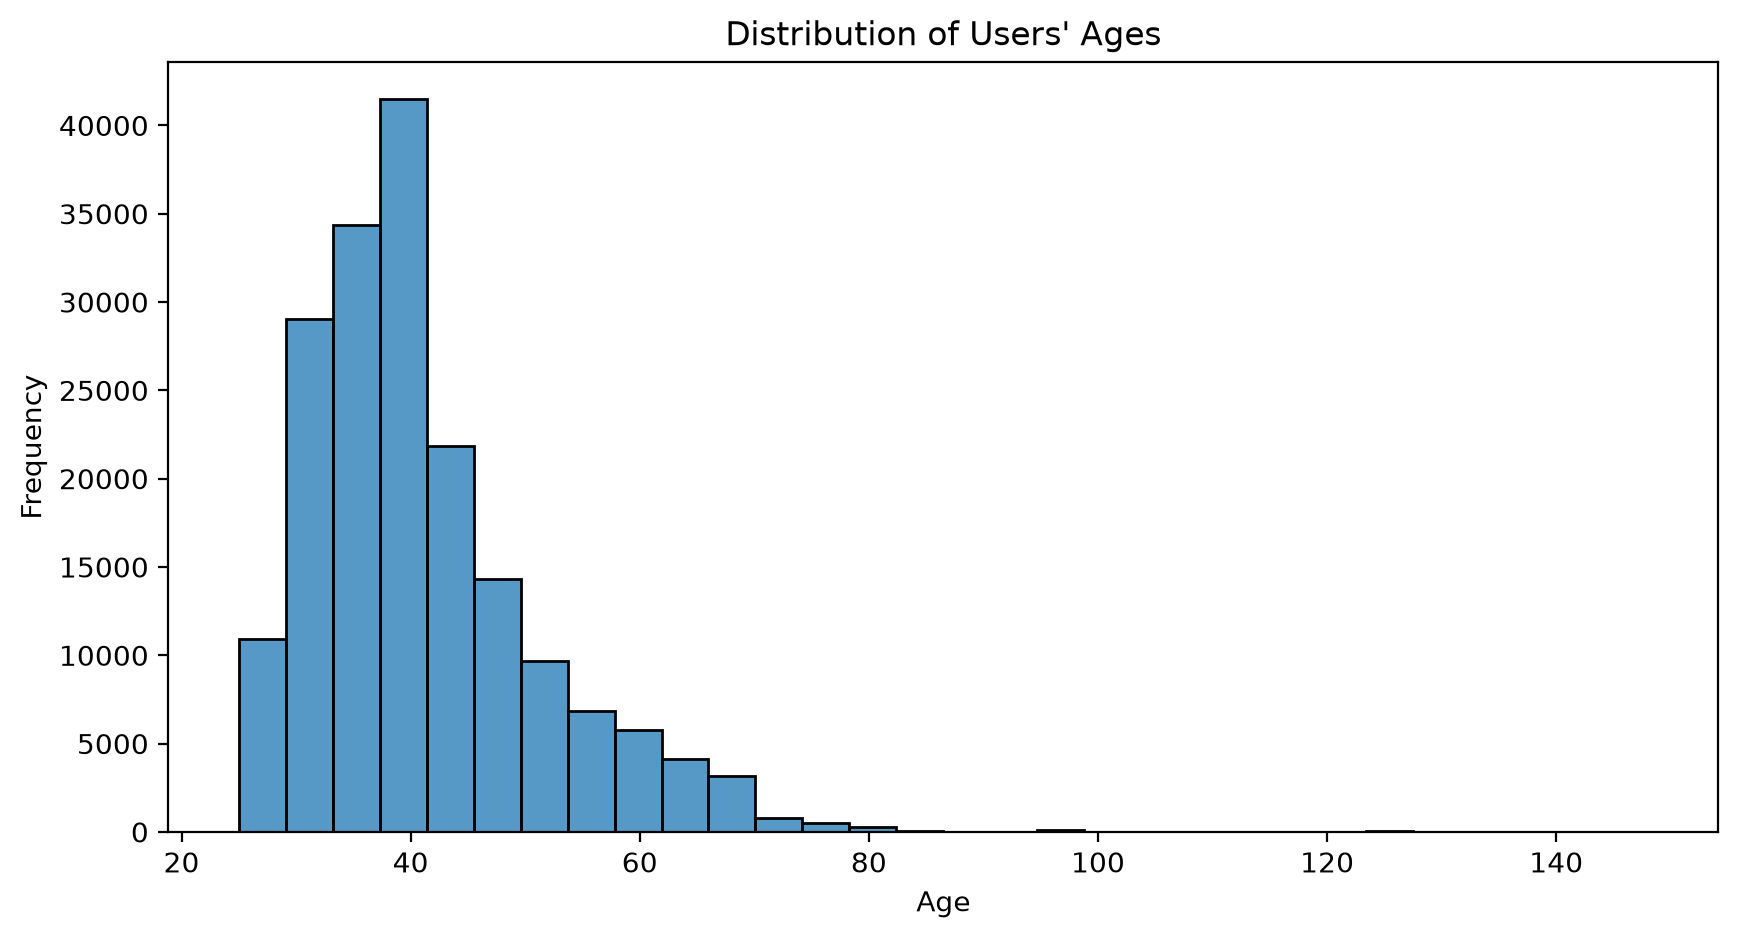

In [117]:
plt.figure(figsize=(10,5), dpi=200)

plot = sns.histplot(data=df, x='users_age', bins=30)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title("Distribution of Users' Ages")

plt.show()

> ### Analysis

The age distribution is concentrated among younger and middle-aged adults, with most observations roughly in the 20s and 30s. A small number of unusually high ages appear in the dataset.


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


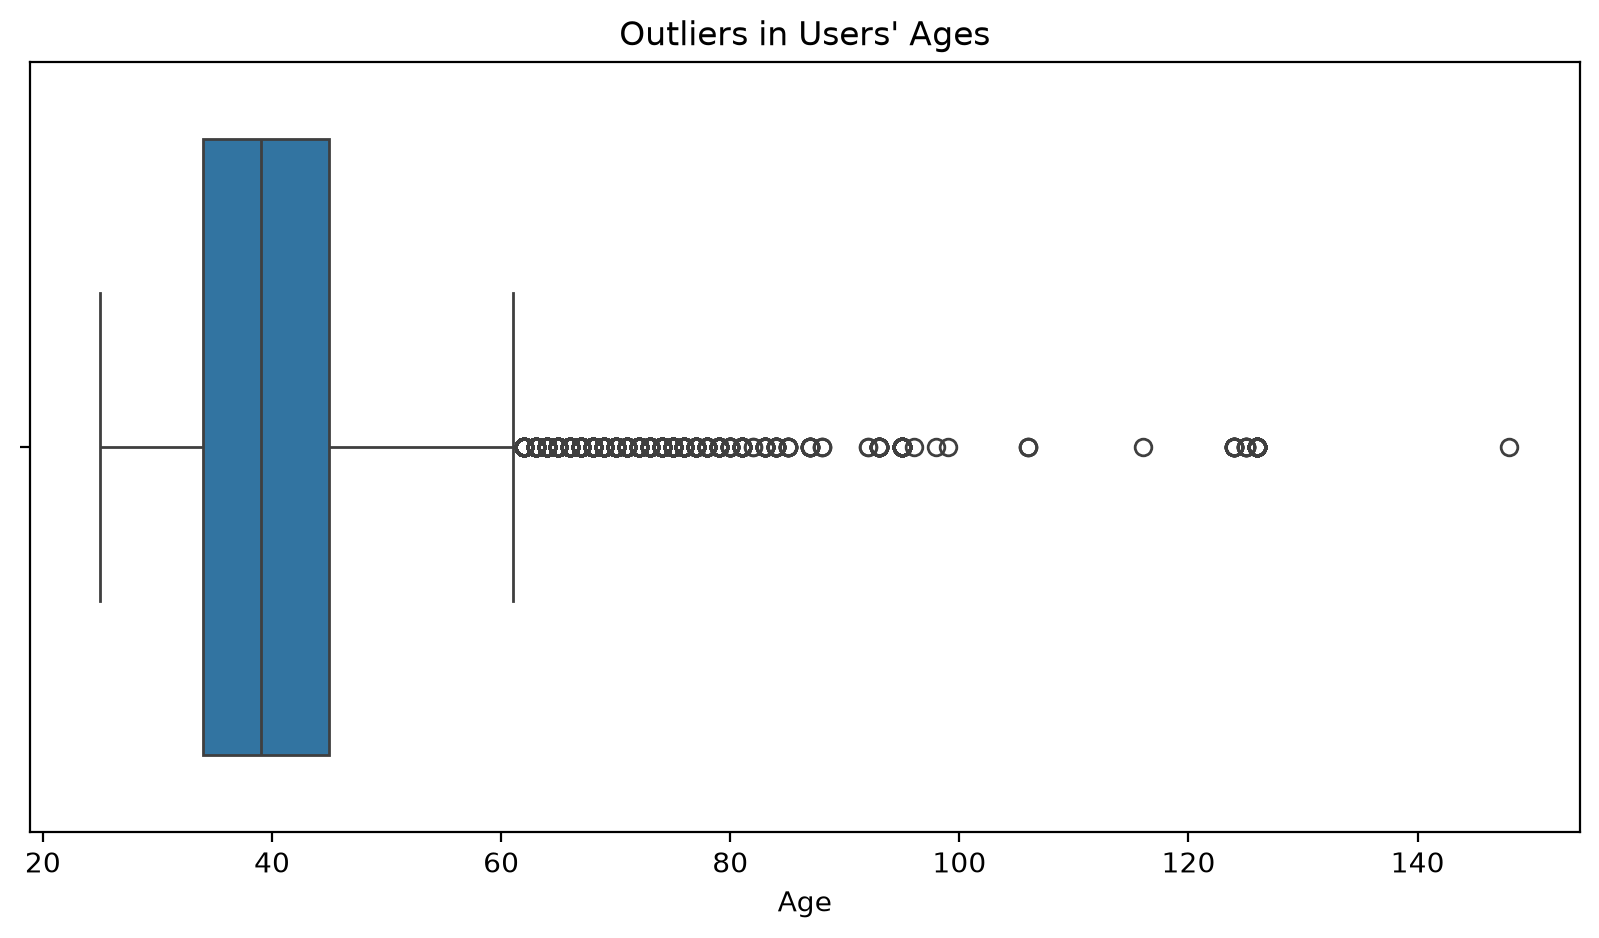

In [119]:
plt.figure(figsize=(10,5), dpi=200)

plot = sns.boxplot(data=df, x='users_age')

plt.xlabel('Age')
plt.title("Outliers in Users' Ages")

plt.show()

> ### Analysis

Yes. The box plot reveals age outliers above 100 years. These values are likely data-quality issues in `member_birth_year` rather than realistic rider ages, so they should be treated cautiously in interpretation.

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [121]:
## Review the statistic for trip duration in minutes
df['duration_min'].describe()


count    183412.000000
mean         11.609393
std          29.908067
min           1.000000
25%           5.000000
50%           8.000000
75%          13.000000
max        1424.000000
Name: duration_min, dtype: float64

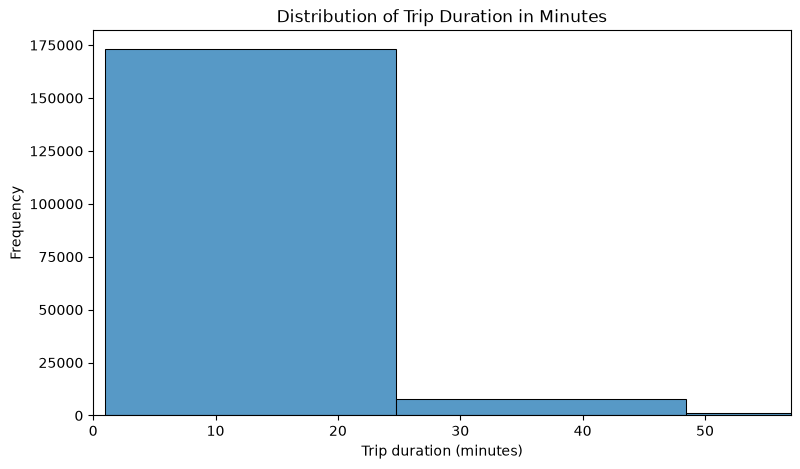

In [125]:
# Make visualization to easy get insight
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x='duration_min', bins=60)
plt.xlim(0, df['duration_min'].quantile(0.99))

plt.xlabel('Trip duration (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Trip Duration in Minutes')

plt.show()

> ### Analysis

Trip duration is strongly right-skewed. Most trips are short, concentrated below about 30 minutes, while a small number of trips last much longer.


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

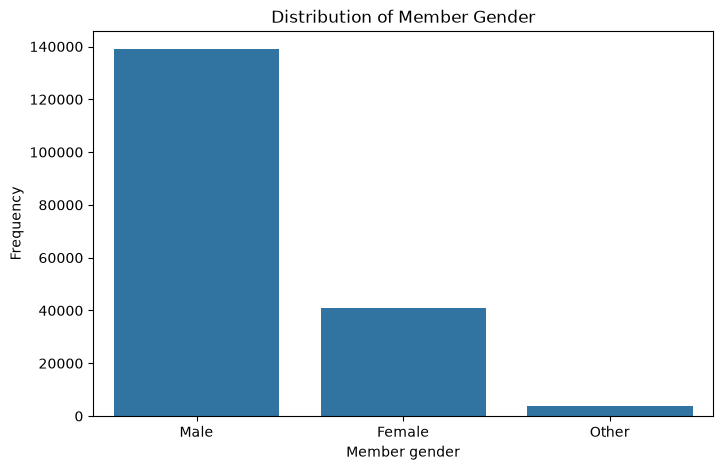

In [128]:
# Make visualization to easy get insight
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='member_gender', order=df['member_gender'].value_counts().index)

plt.xlabel('Member gender')
plt.ylabel('Frequency')
plt.title('Distribution of Member Gender')

plt.show()

> ### Analysis

Male riders are the largest gender group, followed by Female riders. A small `Other` group is present after handling missing gender values.

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

C:\Users\Fahd\AppData\Local\Temp\ipykernel_16620\799705160.py:5: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(0, df['duration_hour'].quantile(0.99))


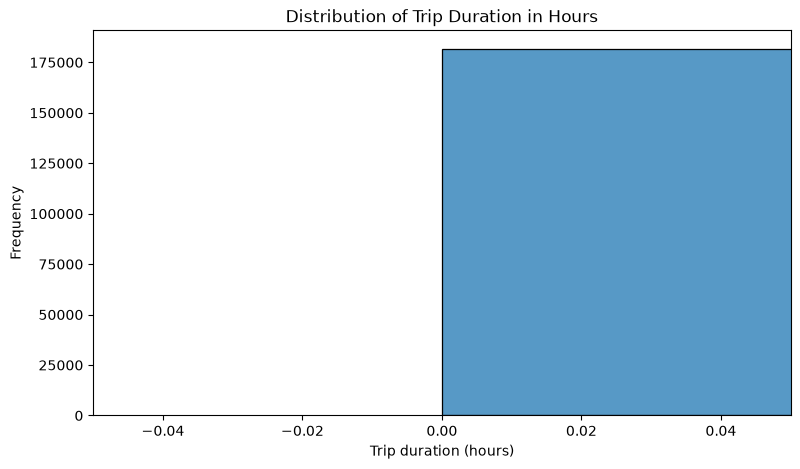

In [130]:
# Make visualization to easy get insight
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x='duration_hour', bins=50)
plt.xlim(0, df['duration_hour'].quantile(0.99))

plt.xlabel('Trip duration (hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Trip Duration in Hours')

plt.show()

> ### Analysis

The hourly distribution confirms the minute-level result: most rides are much shorter than one hour, with a long right tail caused by relatively few long trips.

### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

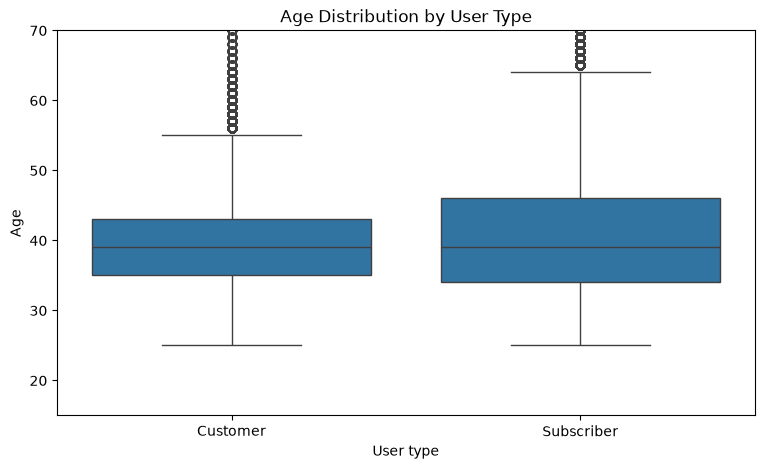

In [134]:
# Distribution of Age by user types
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x='user_type', y='users_age')
plt.ylim(15, df['users_age'].quantile(0.99))

plt.xlabel('User type')
plt.ylabel('Age')
plt.title('Age Distribution by User Type')

plt.show()


# Make visualization to easy get insight


> ### Analysis

Customers tend to have a higher average trip duration than Subscribers. This suggests that occasional users generally spend more time per ride, even though Subscribers account for most trips.

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

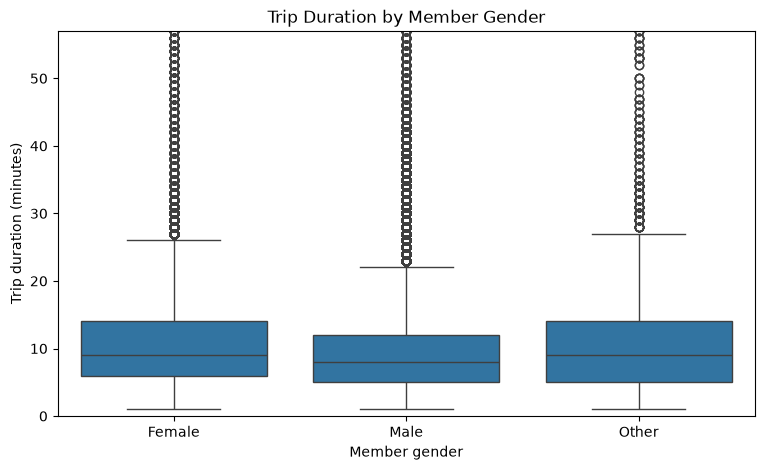

In [ ]:
# Make visualization to easy get insight

# ------------------------Duration distribution by member gender
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x='member_gender', y='duration_min')
plt.ylim(0, df['duration_min'].quantile(0.99))

plt.xlabel('Member gender')
plt.ylabel('Trip duration (minutes)')
plt.title('Trip Duration by Member Gender')

plt.show()


# Make visualization to easy get insight


> ### Analysis

The distributions show differences in trip duration across genders, but the groups also overlap considerably. The average-duration comparison makes the relative differences easier to see.

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

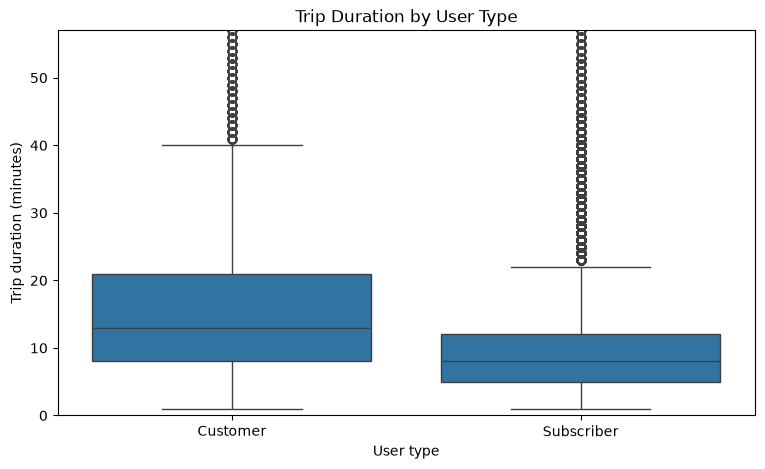

In [137]:

# Make visualization to easy get insight
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x='user_type', y='duration_min')
plt.ylim(0, df['duration_min'].quantile(0.99))

plt.xlabel('User type')
plt.ylabel('Trip duration (minutes)')
plt.title('Trip Duration by User Type')

plt.show()

> ### Analysis

Customers generally have longer trips than Subscribers. Subscribers have many more observations, but their typical trip duration is shorter.

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

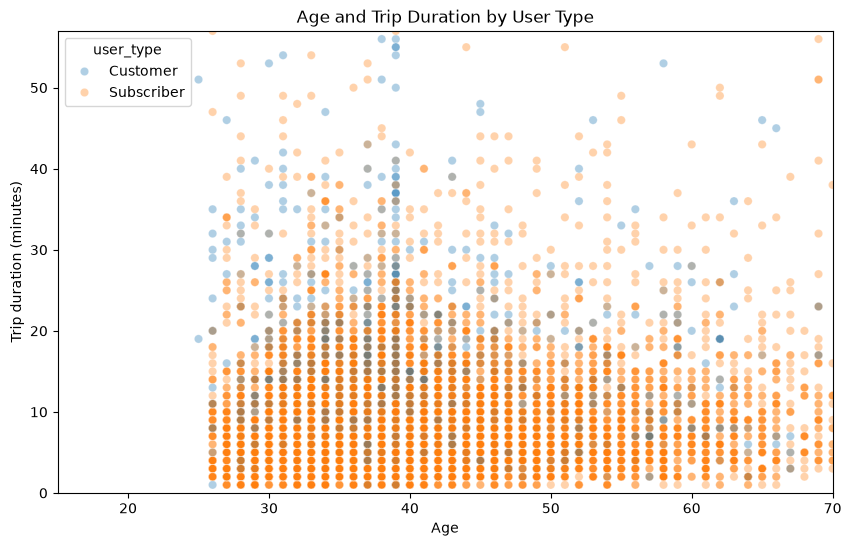

In [139]:

# Make visualization to easy get insight
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df.sample(min(10000, len(df)), random_state=42), x='users_age', y='duration_min', hue='user_type', alpha=0.35)
plt.xlim(15, df['users_age'].quantile(0.99))
plt.ylim(0, df['duration_min'].quantile(0.99))

plt.xlabel('Age')
plt.ylabel('Trip duration (minutes)')
plt.title('Age and Trip Duration by User Type')

plt.show()

> ### Analysis

Age and user type show that most riders are adults in a relatively concentrated age range. Subscribers dominate across the main age groups, while Customers are less numerous and tend to show somewhat longer rides.

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

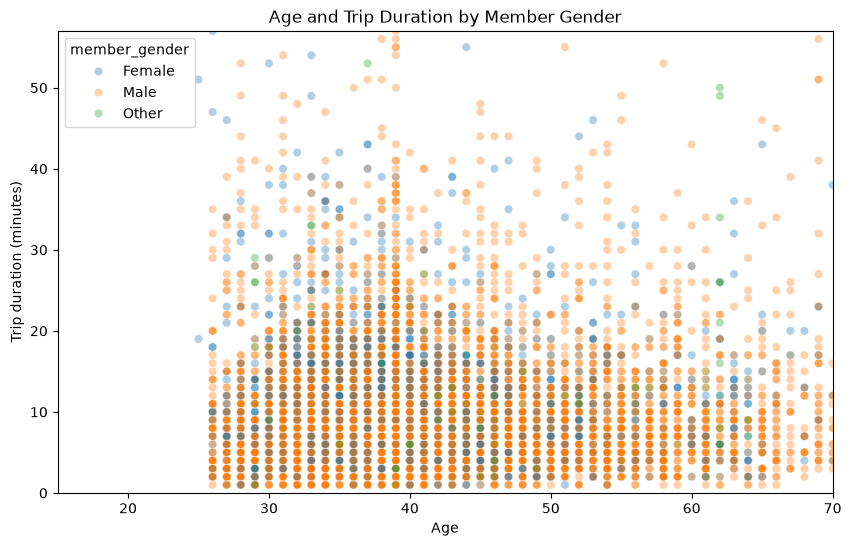

In [141]:
# Make visualization to easy get insight
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(min(10000, len(df)), random_state=42), x='users_age', y='duration_min', hue='member_gender', alpha=0.35)
plt.xlim(15, df['users_age'].quantile(0.99))
plt.ylim(0, df['duration_min'].quantile(0.99))
plt.xlabel('Age')
plt.ylabel('Trip duration (minutes)')
plt.title('Age and Trip Duration by Member Gender')
plt.show()

> ### Analysis

Male riders dominate across the main age range. Female riders form the second-largest group, while Other is comparatively small. The relationship is mainly driven by the different group sizes rather than a strong age-gender pattern.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> The main features showed some interesting relationships with other variables in the dataset. User type had a clear relationship with trip duration, where Customers generally had longer trips than Subscribers. The age distribution showed that most users were young and middle-aged adults, mainly between 22 and 39 years old. There were also differences in trip duration between genders, although the distributions had considerable overlap.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> There were also some interesting relationships between other features. The duration in seconds, minutes, and hours showed a strong positive relationship because they represent the same trip duration in different units. Member birth year and age had a strong negative relationship because younger birth years correspond to older users. The bike_id did not show a meaningful relationship with the other variables.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

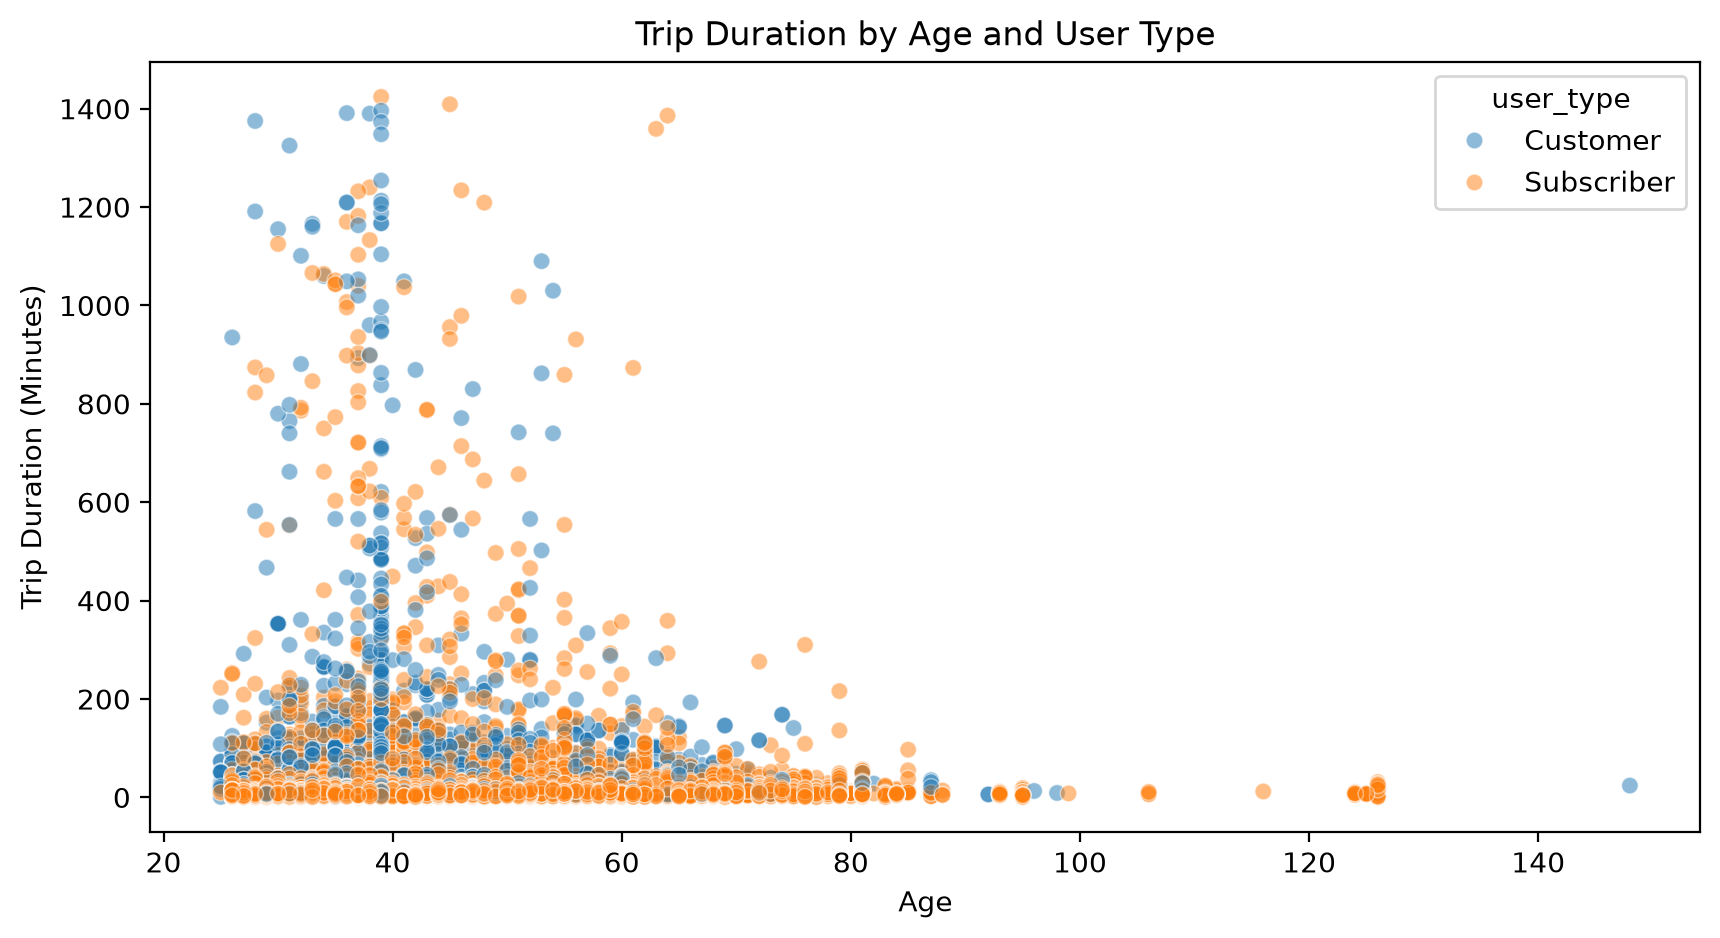

In [142]:
## check your work 
plt.figure(figsize=(10,5), dpi=200)

plot = sns.scatterplot(
    data=df,
    x='users_age',
    y='duration_min',
    hue='user_type',
    alpha=0.5
)

plt.xlabel('Age')
plt.ylabel('Trip Duration (Minutes)')
plt.title('Trip Duration by Age and User Type')

plt.show()


# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

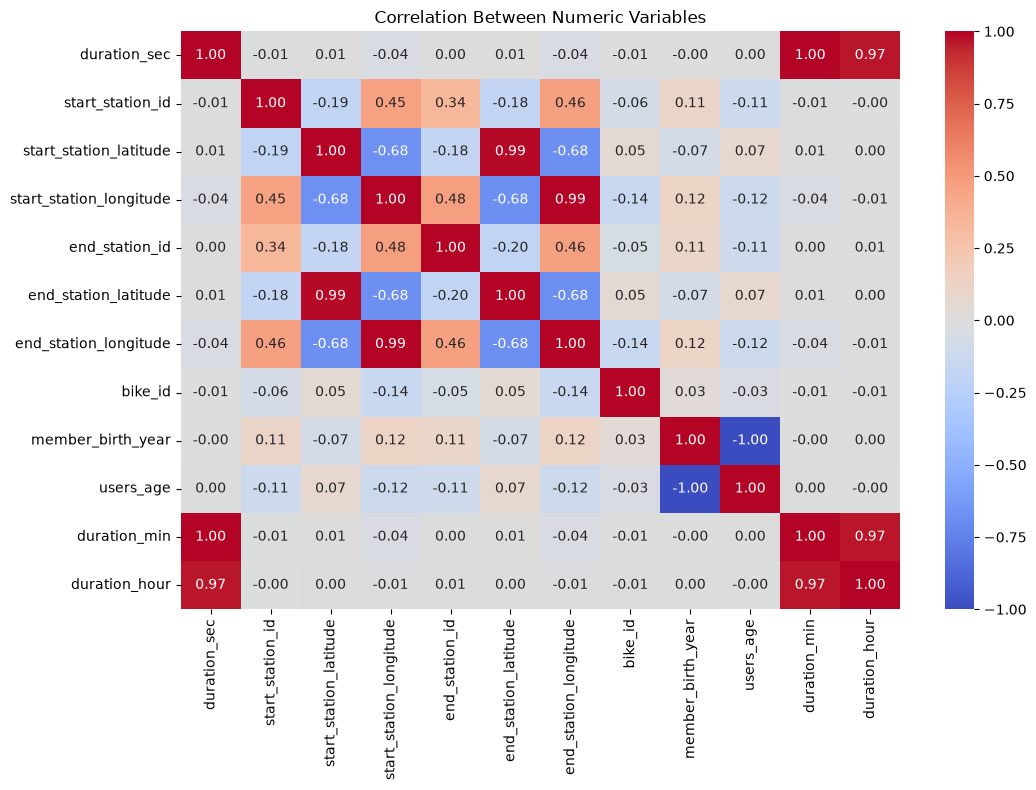

In [144]:
# Make visualization to easy get insight
plt.figure(figsize=(11, 8))

correlation = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Between Numeric Variables')
plt.tight_layout()
plt.show()

> ### Analysis

The correlation matrix shows very strong relationships among `duration_sec`, `duration_min`, and `duration_hour` because these variables are direct unit conversions of the same measure. Age and birth year also have a strong negative relationship because age is calculated from birth year. Other numeric variables show much weaker relationships.


# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


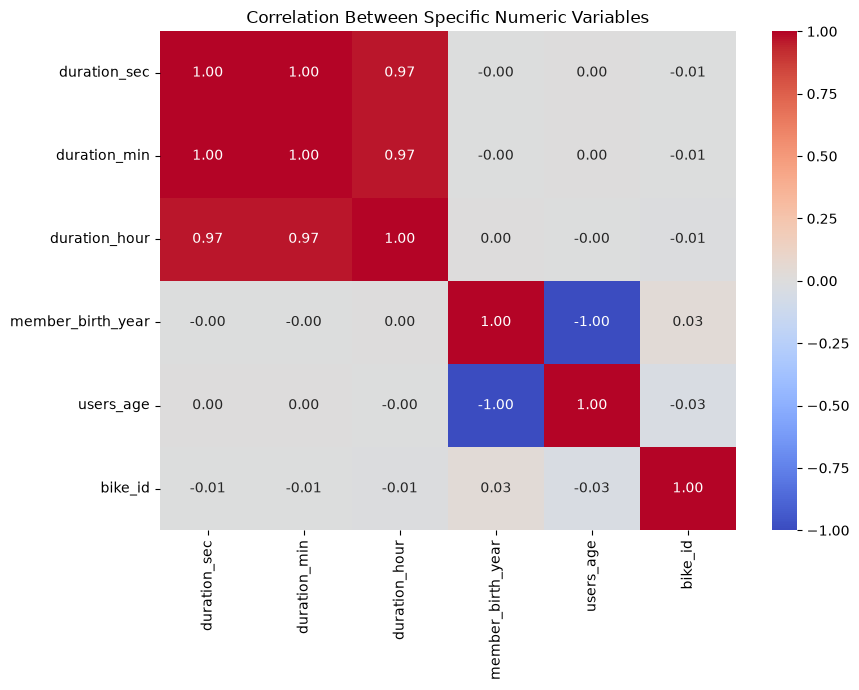

In [148]:
# Make visualization to easy get insight
specific_numeric = ['duration_sec', 'duration_min', 'duration_hour', 'member_birth_year', 'users_age', 'bike_id']
specific_numeric = [c for c in specific_numeric if c in df.columns]

plt.figure(figsize=(9, 7))

sns.heatmap(df[specific_numeric].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Between Specific Numeric Variables')
plt.tight_layout()
plt.show()


> ### Analysis

- `duration_sec`, `duration_min`, and `duration_hour` are almost perfectly positively correlated because they measure the same duration in different units.
- `member_birth_year` and `age` have a strong negative correlation because age is calculated from birth year.
- `bike_id` does not show a meaningful relationship with the main behavioral variables, which is expected because it is an identifier rather than a behavioral measure.

# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


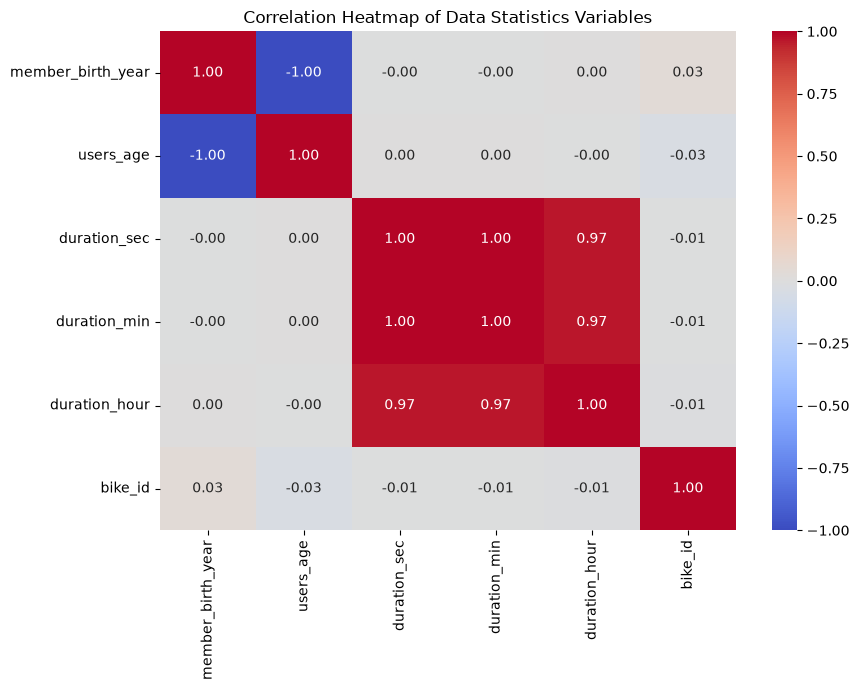

In [149]:

"""""This time I will use heatmap  to explain how Correlation between data_stat variables

in the dataset in more clear and specific percentage"""

# Make visualization to easy get insight
data_stat = df[['member_birth_year', 'users_age', 'duration_sec', 'duration_min', 'duration_hour', 'bike_id']].copy()

plt.figure(figsize=(9, 7))

sns.heatmap(data_stat.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Heatmap of Data Statistics Variables')
plt.tight_layout()
plt.show()


> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /min /hour`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id='1100'> Conclusions </a>

## Main findings
- Most users were Subscribers, not Customers.
- Male riders were the largest gender group.
- Most riders were concentrated in the adult age range, especially the 20s and 30s.
- Most trips were short, usually less than 30 minutes.
- Customers generally had longer average trips than Subscribers.
- Age contained unusual outliers above 100 years that should be interpreted as data-quality issues.

## Limitations
- The dataset contains missing observations that required cleaning.
- Some age values are unrealistic and may affect age-based conclusions.
- Correlation does not imply causation, and `bike_id` is an identifier rather than a meaningful behavioral variable.
